# Estudo de caso — Uruguaiana

Recorte de um único município sobre as três camadas já construídas: Camada 1 (dados,
`outputs/tables/violencia_{mensal,anual}_municipio.csv` e `..._taxa.csv`), Camada 2
(`src/analysis/tendencia.py`, `sazonalidade.py`) e Camada 3 (`autocorrelacao_espacial.py`,
`clusters_lisa.py`). Este notebook não reimplementa nenhuma estatística — só filtra as
mesmas tabelas/funções da pipeline para Uruguaiana e compara contra o estado.

**Por que Uruguaiana:** maior cidade do COREDE Fronteira Oeste, na fronteira com a
Argentina (junto com Barra do Quaraí) às margens do rio Uruguai -- um caso de interesse
para checar se municípios de fronteira têm um padrão de violência diferente do resto do
estado, e se os achados estaduais da Camada 2/3 se replicam num município específico ou
não.

Sete seções: perfil geral, série temporal, ranking estadual, contexto espacial (LISA),
comparação com o COREDE Fronteira Oeste, comparação de porte (fronteira vs. não-fronteira)
e uma síntese final.


In [1]:
import sys

sys.path.insert(0, "..")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import clusters_lisa, sazonalidade, tendencia

TABLES_DIR = Path("../outputs/tables")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

anual = pd.read_csv(TABLES_DIR / "violencia_anual_municipio.csv")
mensal = pd.read_csv(TABLES_DIR / "violencia_mensal_municipio.csv")
taxa = pd.read_csv(TABLES_DIR / "violencia_anual_municipio_taxa.csv")
populacao = pd.read_csv(TABLES_DIR / "populacao_municipio_rs.csv")

MUNICIPIO = "URUGUAIANA"

# Mesma ordem/paleta fixas dos outros três notebooks -- nunca reciclada por
# ranking/filtro, para manter a identidade visual de cada categoria consistente
# em todo o projeto.
CRIME_ORDER = [
    "Ameaça",
    "Estupro",
    "Feminicídio Consumado",
    "Feminicídio Tentado",
    "Lesão Corporal",
]
CRIME_COLORS = {
    "Ameaça": "#2a78d6",
    "Estupro": "#1baf7a",
    "Feminicídio Consumado": "#eda100",
    "Feminicídio Tentado": "#008300",
    "Lesão Corporal": "#4a3aa7",
}
MUTED = "#898781"
GRID = "#e1e0d9"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
ANO_PARCIAL = 2026  # 2026 só tem dados até por volta de junho
POP_MINIMA = 5000
ANO_RECENTE = 2025  # último ano com população estimada (2026 ainda não tem)


def style_ax(ax):
    """Estilo padrão do notebook: sem moldura, grade horizontal sutil."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_SECONDARY, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)


def fmt_milhar(x):
    """Formata número com separador de milhar no padrão brasileiro (1.234)."""
    return f"{x:,.0f}".replace(",", ".")


def salvar(fig, nome):
    fig.savefig(FIGURES_DIR / nome, dpi=150, bbox_inches="tight")


## 1. Perfil geral

Total de casos acumulados (2012-2026), população mais recente (2025) e taxa por 100 mil
hab. acumulada (soma dos casos / soma da população, 2012-2025 -- 2026 fica de fora aqui
por ainda não ter estimativa de população, mesma regra de `correlacao.py`/`load_data.py`),
comparada com a taxa média do estado inteiro.

**Feminicídio Consumado e Feminicídio Tentado são categorias raras** -- poucas dezenas de
casos acumulados em 14 anos. O número absoluto (`n`) aparece ao lado da taxa nos dois:
com contagem tão baixa, a taxa por 100 mil hab. é estatisticamente instável (1-2 casos a
mais ou a menos move a taxa proporcionalmente muito mais do que em Ameaça/Lesão Corporal).


In [2]:
uru_casos_total = (
    anual[anual.municipio == MUNICIPIO].groupby("tipo_crime")["casos_total"].sum().reindex(CRIME_ORDER)
)

pop_2025 = taxa[(taxa.municipio == MUNICIPIO) & (taxa.ano == ANO_RECENTE)]["populacao"].iloc[0]
print(f"População de Uruguaiana em {ANO_RECENTE}: {fmt_milhar(pop_2025)} habitantes")


def taxa_acumulada(municipios):
    """soma(casos)/soma(população) * 100_000 no período com dado de população
    (2012-2025) -- mesma metodologia de correlacao.py, não a média das taxas anuais."""
    base = taxa[(taxa.municipio != "NÃO INFORMADO") & (taxa.municipio.isin(municipios))].dropna(
        subset=["populacao"]
    )
    g = base.groupby("tipo_crime").agg(casos=("casos_total", "sum"), pop_ano=("populacao", "sum"))
    g["taxa_100mil"] = g.casos / g.pop_ano * 100_000
    return g.reindex(CRIME_ORDER)


uru_taxa = taxa_acumulada([MUNICIPIO])
todos_municipios = taxa[taxa.municipio != "NÃO INFORMADO"].municipio.unique()
estado_taxa = taxa_acumulada(todos_municipios)

perfil = pd.DataFrame(
    {
        "casos_2012_2026": uru_casos_total,
        "casos_2012_2025_base_taxa": uru_taxa["casos"],
        "taxa_uruguaiana": uru_taxa["taxa_100mil"],
        "taxa_estado": estado_taxa["taxa_100mil"],
    }
)
perfil["razao_uru_estado"] = (perfil.taxa_uruguaiana / perfil.taxa_estado).round(2)
perfil.round(2)


População de Uruguaiana em 2025: 120.819 habitantes


,casos_2012_2026,casos_2012_2025_base_taxa,taxa_uruguaiana,taxa_estado,razao_uru_estado
tipo_crime,,,,,
Ameaça,5877,5765,327.73,333.72,0.98
Estupro,387,378,21.49,17.67,1.22
Feminicídio Consumado,20,20,1.14,0.82,1.39
Feminicídio Tentado,61,55,3.37,2.53,1.33
Lesão Corporal,4227,4131,234.84,193.65,1.21


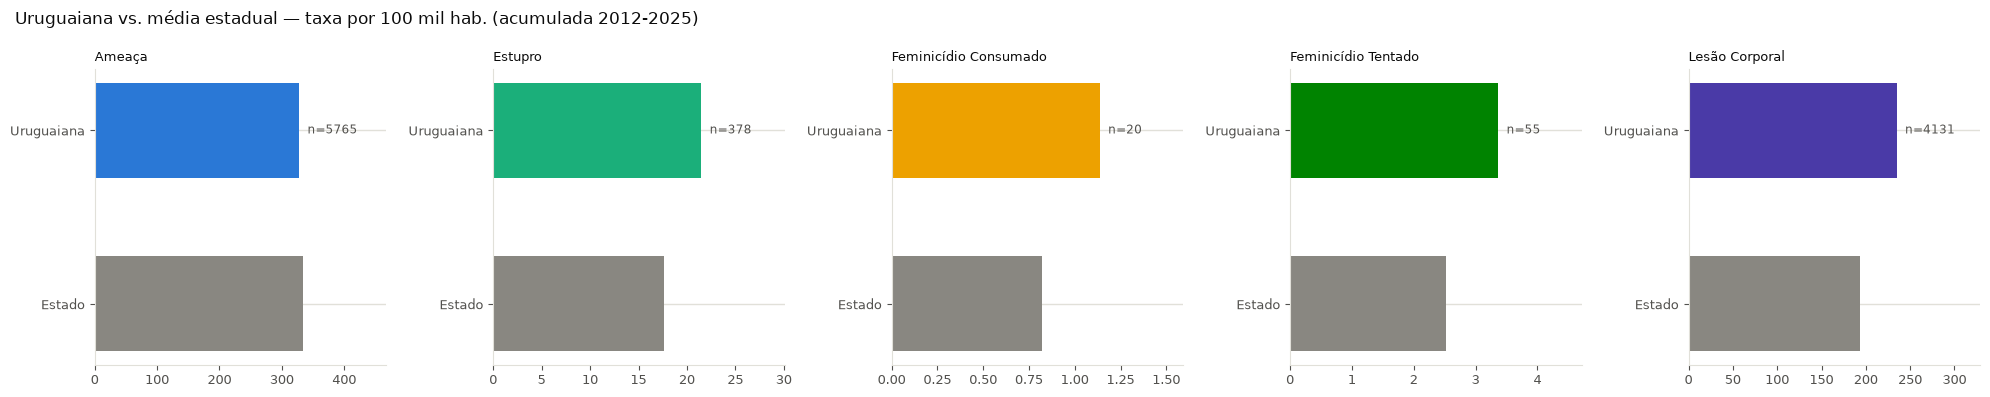

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, tipo in zip(axes, CRIME_ORDER):
    valores = [estado_taxa.loc[tipo, "taxa_100mil"], uru_taxa.loc[tipo, "taxa_100mil"]]
    cores = [MUTED, CRIME_COLORS[tipo]]
    ax.barh(["Estado", "Uruguaiana"], valores, color=cores, height=0.55)

    n = int(uru_taxa.loc[tipo, "casos"])
    ax.text(valores[1] + max(valores) * 0.04, 1, f"n={n}", va="center", fontsize=8.5, color=INK_SECONDARY)
    ax.set_xlim(0, max(valores) * 1.4)
    ax.set_title(tipo, loc="left", fontsize=9.5, color=INK_PRIMARY)
    style_ax(ax)

fig.suptitle(
    "Uruguaiana vs. média estadual — taxa por 100 mil hab. (acumulada 2012-2025)",
    x=0.01, ha="left", color=INK_PRIMARY,
)
fig.tight_layout()
salvar(fig, "uruguaiana_perfil_taxa_vs_estado.png")
plt.show()


## 2. Série temporal de Uruguaiana

Evolução mensal (2018-2026) e anual (2012-2026) por tipo de crime, mesmo espírito visual
do notebook exploratório estadual (2026 sinalizado como parcial). Uma diferença de
formato: lá, as 5 categorias cabem num único eixo em escala log porque são somas do
estado inteiro (nunca exatamente zero); aqui, num único município, Feminicídio Consumado/
Tentado frequentemente têm 0 casos em vários meses/anos -- log não é compatível com zero.
Resolvido com pequenos múltiplos (um painel por categoria, escala linear própria) em vez
de log -- mesmo princípio de nunca comprimir categorias de ordens de grandeza muito
diferentes num eixo só.


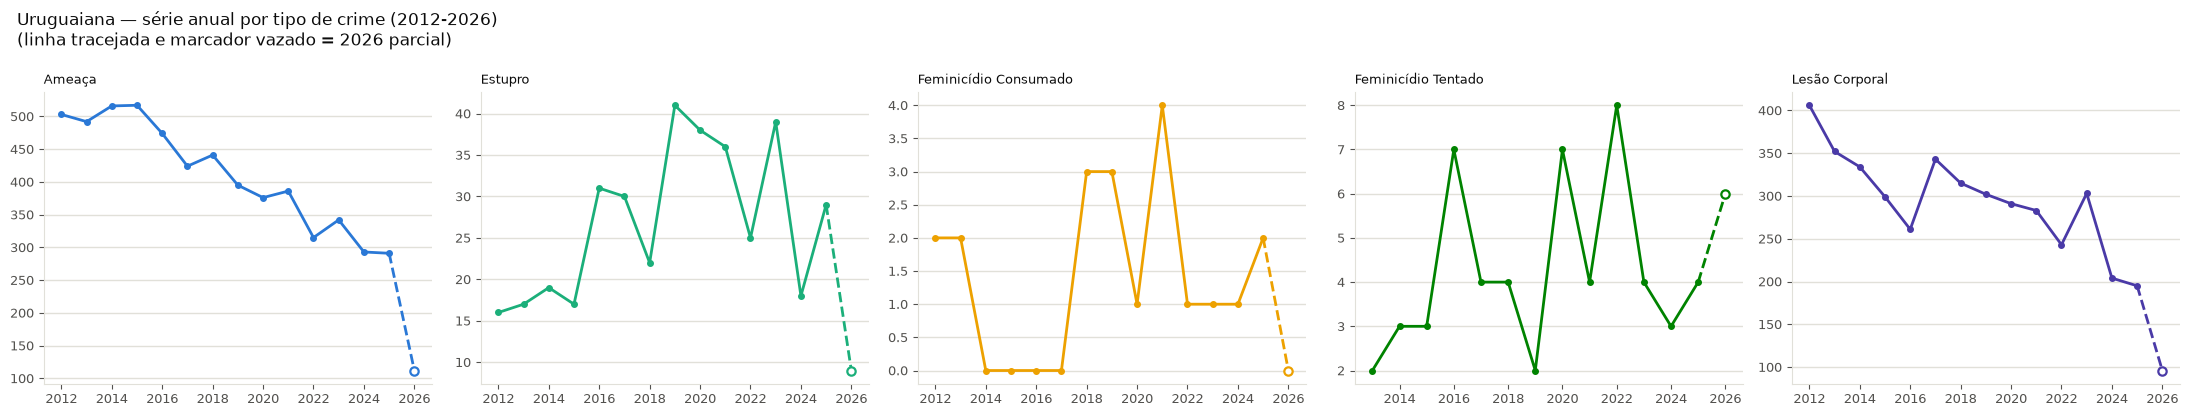

In [4]:
uru_anual_serie = anual[anual.municipio == MUNICIPIO]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, tipo in zip(axes, CRIME_ORDER):
    serie = uru_anual_serie[uru_anual_serie.tipo_crime == tipo].set_index("ano")["casos_total"].sort_index()
    cor = CRIME_COLORS[tipo]

    completos = serie[serie.index < ANO_PARCIAL]
    ax.plot(completos.index, completos.values, color=cor, linewidth=2, marker="o", markersize=4)

    if ANO_PARCIAL in serie.index:
        ultimo_completo = completos.index.max()
        segmento = serie.loc[[ultimo_completo, ANO_PARCIAL]]
        ax.plot(segmento.index, segmento.values, color=cor, linewidth=2, linestyle="--")
        ax.scatter(
            [ANO_PARCIAL], [serie.loc[ANO_PARCIAL]],
            facecolors="white", edgecolors=cor, linewidths=1.6, s=36, zorder=5,
        )

    ax.set_title(tipo, loc="left", fontsize=9.5, color=INK_PRIMARY)
    style_ax(ax)
    ax.xaxis.grid(False)

fig.suptitle(
    "Uruguaiana — série anual por tipo de crime (2012-2026)\n"
    "(linha tracejada e marcador vazado = 2026 parcial)",
    x=0.01, ha="left", color=INK_PRIMARY,
)
fig.tight_layout()
salvar(fig, "uruguaiana_serie_anual.png")
plt.show()


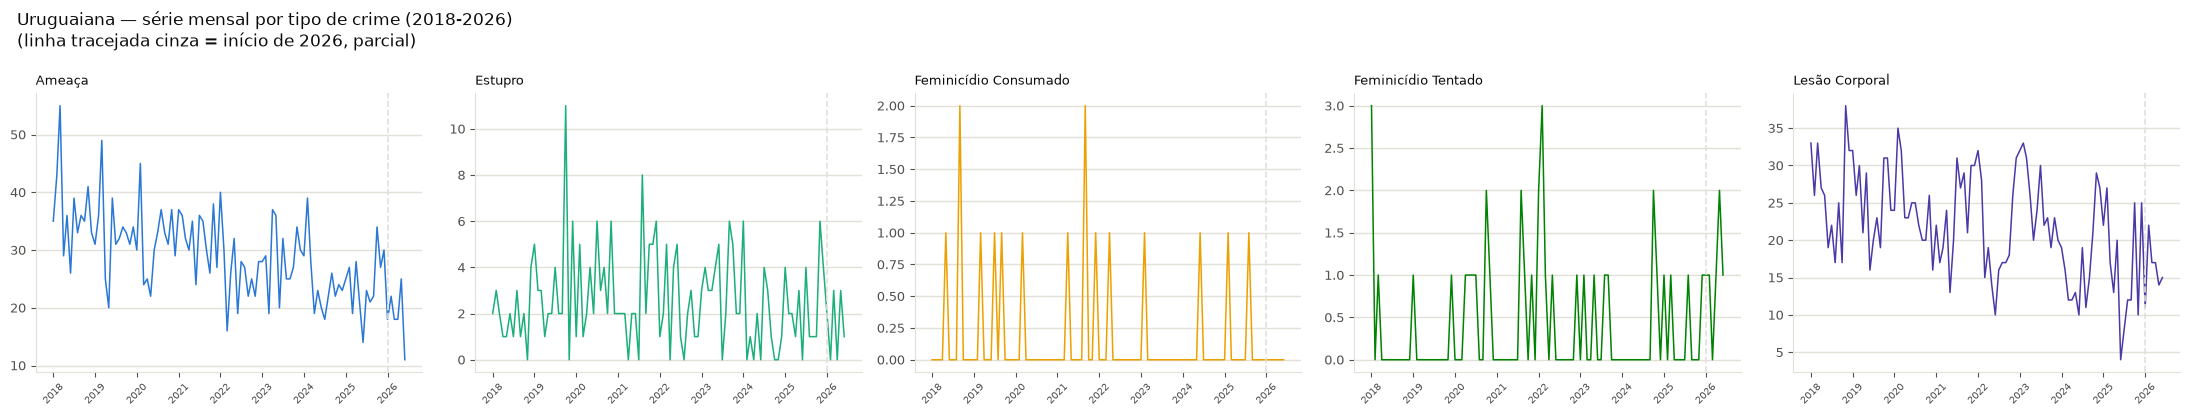

In [5]:
uru_mensal_serie = mensal[mensal.municipio == MUNICIPIO].copy()
uru_mensal_serie["data"] = pd.to_datetime(dict(year=uru_mensal_serie.ano, month=uru_mensal_serie.mes, day=1))

fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, tipo in zip(axes, CRIME_ORDER):
    serie = uru_mensal_serie[uru_mensal_serie.tipo_crime == tipo].sort_values("data")
    ax.plot(serie["data"], serie["casos"], color=CRIME_COLORS[tipo], linewidth=1.1)
    ax.axvline(pd.Timestamp(f"{ANO_PARCIAL}-01-01"), color=GRID, linestyle="--", linewidth=1.2)
    ax.set_title(tipo, loc="left", fontsize=9.5, color=INK_PRIMARY)
    style_ax(ax)
    ax.xaxis.grid(False)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)

fig.suptitle(
    "Uruguaiana — série mensal por tipo de crime (2018-2026)\n"
    "(linha tracejada cinza = início de 2026, parcial)",
    x=0.01, ha="left", color=INK_PRIMARY,
)
fig.tight_layout()
salvar(fig, "uruguaiana_serie_mensal.png")
plt.show()


## 3. Ranking e percentil estadual

Posição de Uruguaiana entre os municípios elegíveis por taxa média anual (2012-2025),
para cada tipo de crime -- mesmo filtro de população mínima da Seção 5.1 do notebook
exploratório (5.000+ habitantes em 2025, para não deixar 1-2 casos isolados num município
minúsculo gerar uma taxa gigante sem significado estatístico).


In [6]:
pop_recente_series = taxa[taxa.ano == ANO_RECENTE].drop_duplicates("municipio").set_index("municipio")["populacao"]
elegiveis = pop_recente_series[pop_recente_series >= POP_MINIMA].index
print(f"Municípios elegíveis (população {ANO_RECENTE} >= {fmt_milhar(POP_MINIMA)}): {len(elegiveis)} de {len(pop_recente_series)}")
print(f"Uruguaiana elegível: {MUNICIPIO in elegiveis}")

base_elegivel = taxa[(taxa.municipio != "NÃO INFORMADO") & (taxa.municipio.isin(elegiveis))]
taxa_media_municipio = base_elegivel.groupby(["tipo_crime", "municipio"])["taxa_por_100mil_hab"].mean().reset_index()

linhas = []
for tipo in CRIME_ORDER:
    grupo = (
        taxa_media_municipio[taxa_media_municipio.tipo_crime == tipo]
        .sort_values("taxa_por_100mil_hab", ascending=False)
        .reset_index(drop=True)
    )
    grupo["posicao"] = grupo.index + 1
    n = len(grupo)
    linha = grupo[grupo.municipio == MUNICIPIO].iloc[0]
    mediana = grupo["taxa_por_100mil_hab"].median()
    linhas.append(
        {
            "tipo_crime": tipo,
            "posicao": int(linha.posicao),
            "n_elegiveis": n,
            "top_pct": round(100 * linha.posicao / n, 1),
            "taxa_uruguaiana": round(linha.taxa_por_100mil_hab, 2),
            "mediana_estadual": round(mediana, 2),
            "acima_da_mediana": bool(linha.taxa_por_100mil_hab > mediana),
        }
    )

ranking_df = pd.DataFrame(linhas)
ranking_df


Municípios elegíveis (população 2025 >= 5.000): 266 de 497
Uruguaiana elegível: True


,tipo_crime,posicao,n_elegiveis,top_pct,taxa_uruguaiana,mediana_estadual,acima_da_mediana
0,Ameaça,119,266,44.7,326.35,309.09,True
1,Estupro,57,266,21.4,21.55,16.14,True
2,Feminicídio Consumado,85,266,32.0,1.14,0.85,True
3,Feminicídio Tentado,50,266,18.8,3.39,2.02,True
4,Lesão Corporal,30,266,11.3,234.30,155.66,True


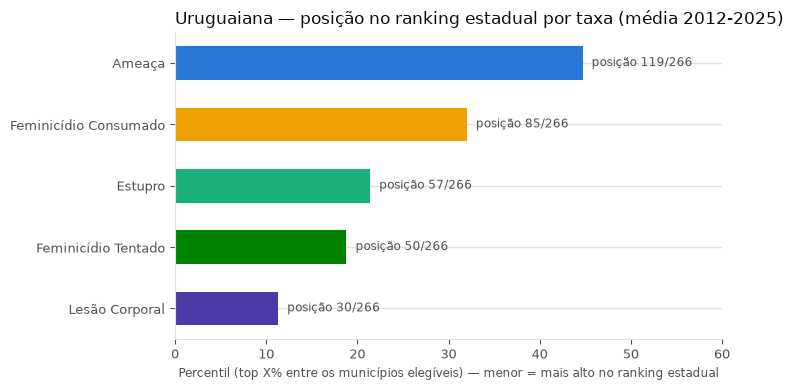

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
plot_df = ranking_df.sort_values("top_pct")
ax.barh(plot_df.tipo_crime, plot_df.top_pct, color=[CRIME_COLORS[t] for t in plot_df.tipo_crime], height=0.55)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row.top_pct + 1, i, f"posição {row.posicao}/{row.n_elegiveis}", va="center", fontsize=8.5, color=INK_SECONDARY)

ax.set_xlim(0, 60)
style_ax(ax)
ax.set_xlabel(
    "Percentil (top X% entre os municípios elegíveis) — menor = mais alto no ranking estadual",
    fontsize=8.5, color=INK_SECONDARY,
)
ax.set_title(
    f"Uruguaiana — posição no ranking estadual por taxa (média {ANO_RECENTE - 13}-{ANO_RECENTE})",
    loc="left", color=INK_PRIMARY,
)
fig.tight_layout()
salvar(fig, "uruguaiana_ranking_percentil.png")
plt.show()


**Leitura:** Uruguaiana fica **acima da mediana estadual nos 5 tipos de crime**. O sinal
mais forte é em **Lesão Corporal** (top 11,3%, posição 30 de 266 municípios elegíveis) --
consistente com o resultado da Seção 4 abaixo. Em **Ameaça** a posição é bem mais próxima
do meio da distribuição (top 44,7%, essencialmente mediana), o tipo de crime em que
Uruguaiana menos se destaca do resto do estado.


## 4. Contexto espacial (LISA)

O Índice de Moran Global (`autocorrelacao_espacial.py`) é uma estatística única para o
estado inteiro, então não tem um "valor para Uruguaiana" -- ele só diz que existe (ou não)
autocorrelação espacial, e para quais tipos de crime (Ameaça, Estupro e Lesão Corporal são
significativos; Feminicídio Consumado/Tentado não). O LISA (`clusters_lisa.py`, que usa a
mesma matriz de pesos espaciais de `autocorrelacao_espacial.py`) é a estatística *local*,
por município -- essa sim tem uma leitura direta para Uruguaiana: ela está dentro de uma
"mancha" regional de taxa alta, ou é estatisticamente isolada da vizinhança?


In [8]:
linhas_lisa = []
for tipo in clusters_lisa.TIPOS_CRIME_PADRAO:
    gdf_tipo, _ = clusters_lisa.calcular_lisa(tipo)
    linha = gdf_tipo[gdf_tipo.municipio == MUNICIPIO].iloc[0]
    linhas_lisa.append(
        {
            "tipo_crime": tipo,
            "categoria_lisa": linha.categoria,
            "taxa_2021_2025": round(linha.taxa_por_100mil_hab, 2),
            "moran_local_i": round(linha.moran_local_i, 3),
            "p_valor_permutacao": round(linha.p_sim, 3),
        }
    )

lisa_uru_df = pd.DataFrame(linhas_lisa)
lisa_uru_df


,tipo_crime,categoria_lisa,taxa_2021_2025,moran_local_i,p_valor_permutacao
0,Ameaça,Não significativo,269.05,0.002,0.440
1,Estupro,Não significativo,24.31,0.028,0.351
2,Lesão Corporal,Alto-Alto,203.07,1.512,0.010


**Leitura:** Uruguaiana só entra num cluster local significativo em **Lesão Corporal**
(Alto-Alto, p=0,010) -- é um hot spot: ela e seus municípios vizinhos formam uma mancha
regional de taxa elevada, não um pico isolado. Em **Ameaça** e **Estupro** a categoria é
"Não significativo" (p=0,44 e p=0,35) -- apesar de estar acima da mediana estadual nas
duas (Seção 3), a taxa de Uruguaiana não é estatisticamente diferente da de seus vizinhos
o suficiente para formar um cluster detectável: é um caso "alto, mas não isolado nem
concentrado regionalmente" nesses dois tipos.


## 5. Comparação regional — COREDE Fronteira Oeste

O COREDE Fronteira Oeste tem 13 municípios: Alegrete, Barra do Quaraí, Itacurubi, Itaqui,
Maçambará, Manoel Viana, Quaraí, Rosário do Sul, Santa Margarida do Sul, Santana do
Livramento, São Borja, São Gabriel e Uruguaiana (fonte: RS/Secretaria da Saúde, tabela
Município×COREDE, conferida contra o perfil socioeconômico da FEE-RS). Taxa geral (todos
os 5 tipos de crime somados), ano a ano.

Uruguaiana é a maior cidade do COREDE (23,1% da população regional em 2025) -- por isso a
"média do COREDE" abaixo **exclui Uruguaiana** do numerador e do denominador (mesma lógica
de "Porto Alegre vs. resto do estado" na Seção 5.2 do notebook exploratório: comparar a
cidade com uma média da qual ela mesma é quase 1/4 amorteceria artificialmente a
diferença).


Uruguaiana representa 23.1% da população do COREDE Fronteira Oeste em 2025.

Médias 2012-2025:
uruguaiana      586.5
corede_resto    561.3
estado          548.7
dtype: float64


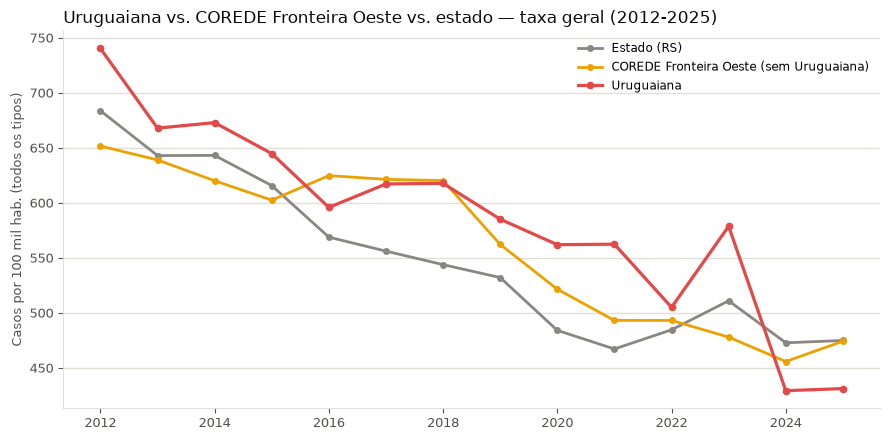

In [9]:
COREDE_FRONTEIRA_OESTE = [
    "ALEGRETE", "BARRA DO QUARAI", "ITACURUBI", "ITAQUI", "MACAMBARA",
    "MANOEL VIANA", "QUARAI", "ROSARIO DO SUL", "SANTA MARGARIDA DO SUL",
    "SANTANA DO LIVRAMENTO", "SAO BORJA", "SAO GABRIEL", "URUGUAIANA",
]

geral_municipio_ano = (
    anual[anual.municipio != "NÃO INFORMADO"]
    .groupby(["municipio", "ano"])["casos_total"].sum().reset_index()
    .merge(populacao, on=["municipio", "ano"], how="inner")
)

pop_corede_recente = populacao[(populacao.municipio.isin(COREDE_FRONTEIRA_OESTE)) & (populacao.ano == ANO_RECENTE)]
share_uru = (
    pop_corede_recente.loc[pop_corede_recente.municipio == MUNICIPIO, "populacao"].iloc[0]
    / pop_corede_recente.populacao.sum() * 100
)
print(f"Uruguaiana representa {share_uru:.1f}% da população do COREDE Fronteira Oeste em {ANO_RECENTE}.")

uru_geral = geral_municipio_ano[geral_municipio_ano.municipio == MUNICIPIO].set_index("ano")
corede_resto = geral_municipio_ano[
    geral_municipio_ano.municipio.isin(COREDE_FRONTEIRA_OESTE) & (geral_municipio_ano.municipio != MUNICIPIO)
]

taxa_uru_geral = uru_geral.casos_total / uru_geral.populacao * 100_000
taxa_corede_resto = corede_resto.groupby("ano").apply(
    lambda g: g.casos_total.sum() / g.populacao.sum() * 100_000, include_groups=False
)
taxa_estado_geral = geral_municipio_ano.groupby("ano").apply(
    lambda g: g.casos_total.sum() / g.populacao.sum() * 100_000, include_groups=False
)

comp_corede = pd.DataFrame(
    {"uruguaiana": taxa_uru_geral, "corede_resto": taxa_corede_resto, "estado": taxa_estado_geral}
).dropna()
print(f"\nMédias 2012-2025:\n{comp_corede.mean().round(1)}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(comp_corede.index, comp_corede.estado, color=MUTED, linewidth=2, marker="o", markersize=4, label="Estado (RS)")
ax.plot(comp_corede.index, comp_corede.corede_resto, color="#eda100", linewidth=2, marker="o", markersize=4, label="COREDE Fronteira Oeste (sem Uruguaiana)")
ax.plot(comp_corede.index, comp_corede.uruguaiana, color="#e34948", linewidth=2.3, marker="o", markersize=4.5, label="Uruguaiana")
style_ax(ax)
ax.xaxis.grid(False)
ax.set_ylabel("Casos por 100 mil hab. (todos os tipos)", fontsize=9, color=INK_SECONDARY)
ax.set_title("Uruguaiana vs. COREDE Fronteira Oeste vs. estado — taxa geral (2012-2025)", loc="left", color=INK_PRIMARY)
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
fig.tight_layout()
salvar(fig, "uruguaiana_vs_corede_vs_estado.png")
plt.show()


**Leitura:** Uruguaiana fica acima da taxa do estado na maior parte do período (12 dos 14
anos) e acima do resto do COREDE em 9 dos 14 anos -- taxa geral consistentemente no topo
dos três, mas sem um distanciamento enorme (médias 2012-2025: Uruguaiana 586,5, resto do
COREDE 561,3, estado 548,7). As três séries caem na mesma direção geral ao longo do
período, sem sinal de que Uruguaiana esteja indo na contramão da sua região ou do estado.


## 6. Comparação de porte — efeito fronteira vs. efeito porte

Dois eixos de comparação, ambos com municípios de porte populacional parecido (2025):
Uruguaiana (120.819), Bagé (121.928), Santa Cruz do Sul (138.270), Bento Gonçalves
(127.977) e Erechim (109.609).

- **(a) Efeito fronteira**: Uruguaiana vs. Bagé -- as duas são cidades de fronteira
  (Argentina e Uruguai, respectivamente) de porte semelhante.
- **(b) Efeito porte sem fronteira**: Uruguaiana vs. a média de Santa Cruz do Sul, Bento
  Gonçalves e Erechim -- três polos regionais do interior, porte semelhante, sem fronteira
  internacional.

Taxa geral (todos os 5 tipos somados), num único gráfico com o estado como referência.


Médias 2012-2025:
uruguaiana                   586.5
bage                         575.8
grupo_porte_sem_fronteira    675.8
estado                       548.7
dtype: float64


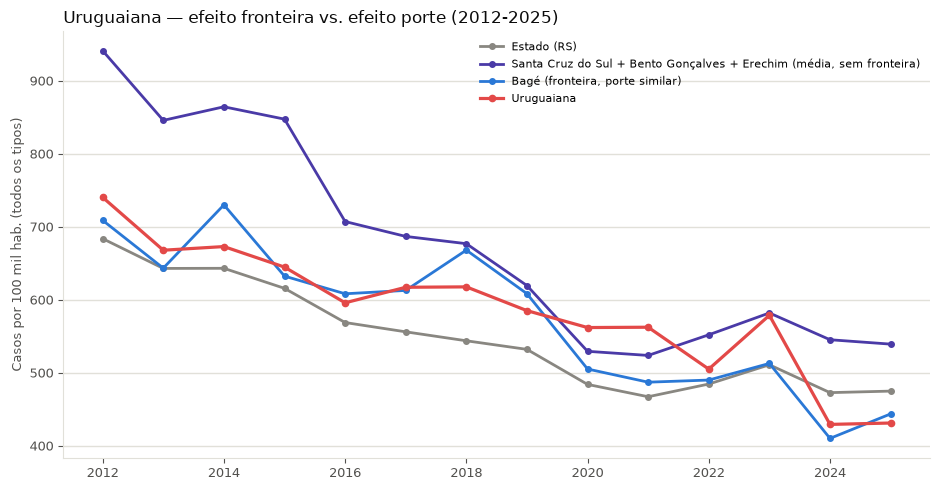

In [10]:
GRUPO_PORTE_SEM_FRONTEIRA = ["SANTA CRUZ DO SUL", "BENTO GONCALVES", "ERECHIM"]


def taxa_municipio(nome):
    g = geral_municipio_ano[geral_municipio_ano.municipio == nome].set_index("ano")
    return g.casos_total / g.populacao * 100_000


taxa_bage = taxa_municipio("BAGE")
grupo_porte = geral_municipio_ano[geral_municipio_ano.municipio.isin(GRUPO_PORTE_SEM_FRONTEIRA)]
taxa_grupo_porte = grupo_porte.groupby("ano").apply(
    lambda g: g.casos_total.sum() / g.populacao.sum() * 100_000, include_groups=False
)

comp_porte = pd.DataFrame(
    {
        "uruguaiana": taxa_uru_geral,
        "bage": taxa_bage,
        "grupo_porte_sem_fronteira": taxa_grupo_porte,
        "estado": taxa_estado_geral,
    }
).dropna()
print(f"Médias 2012-2025:\n{comp_porte.mean().round(1)}")

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(comp_porte.index, comp_porte.estado, color=MUTED, linewidth=2, marker="o", markersize=4, label="Estado (RS)")
ax.plot(comp_porte.index, comp_porte.grupo_porte_sem_fronteira, color="#4a3aa7", linewidth=2, marker="o", markersize=4, label="Santa Cruz do Sul + Bento Gonçalves + Erechim (média, sem fronteira)")
ax.plot(comp_porte.index, comp_porte.bage, color="#2a78d6", linewidth=2, marker="o", markersize=4, label="Bagé (fronteira, porte similar)")
ax.plot(comp_porte.index, comp_porte.uruguaiana, color="#e34948", linewidth=2.3, marker="o", markersize=4.5, label="Uruguaiana")
style_ax(ax)
ax.xaxis.grid(False)
ax.set_ylabel("Casos por 100 mil hab. (todos os tipos)", fontsize=9, color=INK_SECONDARY)
ax.set_title("Uruguaiana — efeito fronteira vs. efeito porte (2012-2025)", loc="left", color=INK_PRIMARY)
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
salvar(fig, "uruguaiana_porte_fronteira.png")
plt.show()


**Leitura -- contraintuitiva:** o "efeito fronteira" não aparece nos dados da forma que
se poderia esperar. Uruguaiana (586,5) e Bagé (575,8) -- as duas cidades de fronteira --
têm taxas médias parecidas entre si, e **abaixo** da média do grupo de porte semelhante
sem fronteira (675,8: Santa Cruz do Sul, Bento Gonçalves, Erechim). Ou seja, nesta
comparação de 5 municípios a taxa geral de violência não distingue claramente cidade de
fronteira de polo regional do interior -- se alguma coisa, os polos do interior sem
fronteira aparecem *mais* altos, não menos.

**Ressalva importante:** isto é uma comparação descritiva de poucos municípios (n=1 e n=3
por grupo), não um teste estatístico com poder para separar "efeito fronteira" de
variação normal entre municípios de porte parecido -- não deve ser lido como prova de que
fronteira não importa, só como um achado que não confirma a hipótese inicial e merece
investigação com mais municípios de cada grupo antes de qualquer conclusão mais forte.


## 7. Síntese

Comparação direta entre os testes da Camada 2 rodados para o estado inteiro e os mesmos
testes (`tendencia.testar_tendencia`, `sazonalidade.testar_sazonalidade`) rodados só
sobre a série de Uruguaiana, para checar se os padrões estaduais se replicam no município.


In [11]:
uru_anual_2018_2025 = anual[(anual.municipio == MUNICIPIO) & (anual.ano >= 2018) & (anual.ano <= 2025)]
uru_tendencia = tendencia.testar_tendencia(uru_anual_2018_2025)
estado_tendencia = tendencia.main()

comparacao_tendencia = uru_tendencia[["tipo_crime", "slope", "p_valor_linregress", "significativo_linregress_5pct"]].merge(
    estado_tendencia[["tipo_crime", "slope", "p_valor_linregress", "significativo_linregress_5pct"]],
    on="tipo_crime", suffixes=("_uruguaiana", "_estado"),
)
comparacao_tendencia


,tipo_crime,slope_uruguaiana,p_valor_linregress_uruguaiana,significativo_linregress_5pct_uruguaiana,slope_estado,p_valor_linregress_estado,significativo_linregress_5pct_estado
0,Ameaça,-20.630952,0.000445,True,-841.857143,0.009960,True
1,Estupro,-0.880952,0.552952,False,136.000000,0.023234,True
2,Feminicídio Consumado,-0.238095,0.219944,False,-4.035714,0.086390,False
3,Feminicídio Tentado,0.000000,1.000000,False,-17.785714,0.006374,True
4,Lesão Corporal,-15.880952,0.010818,True,-371.321429,0.077570,False


In [12]:
uru_mensal_para_sazonalidade = mensal[mensal.municipio == MUNICIPIO][["tipo_crime", "ano", "mes", "casos"]]
uru_sazonalidade = sazonalidade.testar_sazonalidade(uru_mensal_para_sazonalidade)
estado_sazonalidade, _ = sazonalidade.main()

comparacao_sazonalidade = uru_sazonalidade[["tipo_crime", "estatistica_h", "p_valor", "significativo_5pct"]].merge(
    estado_sazonalidade[["tipo_crime", "estatistica_h", "p_valor", "significativo_5pct"]],
    on="tipo_crime", suffixes=("_uruguaiana", "_estado"),
)
comparacao_sazonalidade


,tipo_crime,estatistica_h_uruguaiana,p_valor_uruguaiana,significativo_5pct_uruguaiana,estatistica_h_estado,p_valor_estado,significativo_5pct_estado
0,Ameaça,14.075748,0.228830,False,59.661513,1.071583e-08,True
1,Estupro,11.486683,0.403436,False,23.475226,1.513646e-02,True
2,Feminicídio Consumado,10.229501,0.509869,False,12.082234,3.574938e-01,False
3,Feminicídio Tentado,6.602096,0.830331,False,15.741695,1.509945e-01,False
4,Lesão Corporal,20.197666,0.042702,True,76.883252,5.891735e-12,True


**Síntese dos achados sobre Uruguaiana:**

- **Tendência (2018-2025):** a queda de Ameaça observada no estado (p=0,010) **se
  replica em Uruguaiana**, e com sinal ainda mais forte localmente (p=0,0004,
  Mann-Kendall p=0,0017). Já a alta de Estupro que é significativa no estado (p=0,023)
  **não aparece em Uruguaiana** (p=0,553, sem tendência detectável). Na direção oposta,
  Lesão Corporal tem queda significativa em Uruguaiana (p=0,011) que o estado como um
  todo **não** mostra (p=0,078, abaixo do corte de 5%) -- um padrão que é local, não
  visível na agregação estadual.
- **Sazonalidade:** Ameaça e Estupro têm diferença significativa entre meses no estado,
  mas **não** em Uruguaiana isoladamente (p=0,229 e p=0,403) -- n baixo por mês num único
  município reduz bastante o poder do teste, então isso não significa necessariamente
  "sem sazonalidade real ali", só "não detectável com esse tamanho de amostra". Lesão
  Corporal é a exceção: sazonalidade significativa tanto no estado (p=5,9e-12) quanto em
  Uruguaiana (p=0,043, mais marginal).
- **Ranking (Seção 3):** acima da mediana estadual nos 5 tipos de crime, com destaque
  para Lesão Corporal (top 11,3%).
- **Contexto espacial (Seção 4):** hot spot (Alto-Alto) só em Lesão Corporal -- Uruguaiana
  faz parte de uma mancha regional de taxa alta nesse tipo específico, mas não em
  Ameaça/Estupro, onde sua taxa elevada não forma cluster com a vizinhança.
- **Região (Seção 5):** consistentemente um pouco acima do resto do COREDE Fronteira
  Oeste e do estado, sem uma ruptura clara de padrão.
- **Porte vs. fronteira (Seção 6):** o achado mais contraintuitivo do notebook -- a
  hipótese de "cidade de fronteira tem mais violência" não se sustenta nesta comparação
  de 5 municípios; os polos do interior sem fronteira (Santa Cruz do Sul, Bento
  Gonçalves, Erechim) têm taxa geral média mais alta que as duas cidades de fronteira
  (Uruguaiana e Bagé).

**Leitura geral:** Uruguaiana não é um caso atípico dramático -- está consistentemente
acima da mediana/média estadual e regional, mas por margens moderadas, e o único cluster
espacial local significativo é em Lesão Corporal. O achado mais informativo talvez seja
metodológico: tendência e sazonalidade estaduais **nem sempre se replicam** no nível de
um único município (Estupro é o exemplo mais claro), o que é um lembrete de que a Camada
2 descreve o estado como um todo, não necessariamente cada município individualmente.
